# Hyperparameter selection — on the cold-item VALIDATION population

This notebook exists so that `baseline_steel_thread_cf` never chooses a hyperparameter by looking
at the number it reports. Anything selected here is selected on `dataset.cold_val` — a second,
disjoint population of 2,727 cold items drawn from the same eligible pool by the same rule as the
reported test set, and likewise absent from `ref_train` (see `load.load_dataset`'s 80/10/10 split).

**Why not `ref_val`?** `ref_val` holds out *warm* interactions, so it answers "what mix is best in
general", not "what mix is best for cold-item retrieval". `cold_val` asks the same question the
experiment asks.

**Output:** `../outputs/hyperparams.json`, stamped with the dataset fingerprint. The steel thread
loads it, prints the provenance, and **refuses to use it against a different split** — so a value
tuned on one dataset can never silently leak into a run on another.

This notebook writes only the `cbhcf` key; the other sections of that file (`intervention_a`,
`intervention_a_description`, `intervention_a_weight_sweep`, `steel_thread_config`) are written by
their own notebooks and are preserved on a re-run. Note it REPLACES `cbhcf` wholesale, so anything
added to that key out-of-band would be lost — which is why the per-lambda AUC below is persisted
here rather than patched in afterwards by a separate script.

**Currently tuned:** CBHCF's content weight `lambda`.

**Not tuned yet — an open design question.** The ALS config (`factors`, `regularization`,
`iterations`) was chosen to be converged, not searched. If CBHCF gets a tuning budget and ALS does
not, some of any CBHCF advantage is tuning effort rather than content signal. Either give ALS the
same search here, or report CBHCF at both the default and the tuned lambda. See `OPEN_TODOS.md`.

In [ ]:
%%time
import hashlib
import json
import os
import pickle
import sys
import time

sys.path.insert(0, "..")

import numpy as np
import matplotlib
try:
    get_ipython()
except NameError:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from recsys import load, cf, content, cbhcf, eval as ev

DEVICE = "cuda:1"
DATA_PATH = "../data/filtered/books_5core_common.parquet"
SPLIT_PARAMS = dict(cold_item_fraction=0.10, cold_val_fraction=0.10)


def cache_pickle(name, compute, params=None):
    tag = "" if params is None else "_" + hashlib.md5(repr(params).encode()).hexdigest()[:8]
    path = f"../data/cache/{name}{tag}.pkl"
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    val = compute()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(val, f, protocol=pickle.HIGHEST_PROTOCOL)
    return val


dataset = cache_pickle("books_dataset", lambda: load.load_dataset(data_path=DATA_PATH, **SPLIT_PARAMS),
                       params=load.load_params_fingerprint(DATA_PATH, **SPLIT_PARAMS))
FP = load.dataset_fingerprint(dataset)
if dataset.cold_val is None:
    raise RuntimeError("this dataset has no validation cold population; rebuild with cold_val_fraction > 0")
val = dataset.cold_val
print(f"test cold items {len(dataset.cold_item_ids):,}   validation cold items {len(val.cold_item_ids):,}")
print(f"dataset fingerprint: {FP}")

test cold items 2,727   validation cold items 2,727
dataset fingerprint: (384339, 487790, 2676601, 345998, 347561, 2727, 633483902, 13635, 2727, 625156242)
CPU times: user 309 ms, sys: 489 ms, total: 798 ms
Wall time: 1.72 s


## The search grid

**lambda values.** `content.py`'s scaling divides each term by its own spread, so `lambda = 1` means "the
content term contributes as much spread as the collaborative term". The grid is log-spaced around
that, which is where the interesting range must be.

**k levels.** The objective is a *mean over reveal levels*, not a single point. Selecting at `k=0`
alone is a trap: a cold item's collaborative score is exactly zero there, so nothing counterweighs
pushing lambda up, and the chosen value would be actively harmful at large k. A coarse grid of levels
plus the within-item ceiling gives both ends of the lifecycle at ~5% of the cost of the full
21-level sweep.

**The ceiling matters most here.** It is each cold item with its *entire* pre-test history (median
33 interactions, max 1,754). If lambda* stays high with the ceiling in the objective, that is direct
evidence content keeps earning its place at high degree — the claim that removed the old
annealing ramp. If lambda* collapses, that is evidence the other way. Either result is worth having.

**Seeds.** lambda is very unlikely to interact strongly with ALS's random initialization, so the search
runs at `N_SEEDS_TUNE` and only the winning lambda is re-run at the full ensemble in the steel thread.

In [ ]:
%%time
LAMBDA_GRID = [0.0, 4.0, 6.0, 8.0, 12.0, 16.0, 24.0, 32.0, 48.0, 64.0, 1e6]
# 0.0 == pure ALS (the control); 1e6 == effectively pure content (the asymptote). The first pass
# over [0, 0.05, 0.1, 0.25, 0.5, 1, 2, 4] rose monotonically and hit the upper edge at 4.0, so this
# pass extends upward to find where it plateaus.
K_LEVELS_TUNE = [0, 2, 5, 10, 20]
CEILING_WEIGHT = 1.0        # weight of the ceiling point relative to ONE k level in the mean
K = 100
N_SEEDS_TUNE = 2
SELECTOR = "NDCG"           # headline metric elsewhere; AUC is reported alongside as a cross-check
ALS_PARAMS = dict(factors=64, regularization=0.01, iterations=20)

# --- The warm-item guard ------------------------------------------------------------------------
# cold_val measures ONLY cold-item retrieval, so the objective above is blind to what a large lambda
# does to everything else. Left unconstrained it climbs monotonically toward pure content, because
# discarding the collaborative signal costs nothing that cold_val can see -- while in reality the
# same lambda applies to the whole catalogue, and warm items are exactly where that signal is
# strong. Selecting on cold_val alone would happily ship a model that is better at cold start and
# worse at recommending.
#
# So: maximize cold-item retrieval SUBJECT TO warm-item retrieval staying within WARM_TOLERANCE of
# the BEST warm score the grid achieves. `ref_val` is the instrument -- the per-user leave-last-out
# warm holdout that load.py has always built and nothing has used until now.
#
# Note the reference is the best achievable warm score, NOT the pure-ALS control. Measured on this
# data, content *improves* warm-item retrieval about 3.2x over pure ALS (0.0170 -> 0.0536), so
# anchoring the floor to lambda=0 would make it trivially clearable and the constraint vacuous.
# Warm quality peaks at a low lambda and declines from there, so anchoring to the peak asks the
# question that actually matters: how much warm-item quality is this lambda giving up?
WARM_TOLERANCE = 0.02       # allow at most a 2% relative drop from the BEST warm NDCG@K in the grid
N_WARM_EVAL = 10_000        # sampled users with a held-out ref_val interaction (347k is overkill)

als_seeds = cache_pickle(
    "als_seeds_tune",
    lambda: [cf.ALSModel(random_state=s, **ALS_PARAMS).fit(dataset.ref_train)
             for s in range(N_SEEDS_TUNE)],
    params=(FP, tuple(sorted(ALS_PARAMS.items())), N_SEEDS_TUNE))
# Pools are built against the VALIDATION cold population, so every ranking here competes cold_val
# items against the same warm catalogue the test run uses.
for m in als_seeds:
    m.prepare_gpu_recommend(val, candidates="warm_cold", device=DEVICE)
print(f"{len(als_seeds)} ALS fits ready (candidate pool: {len(als_seeds[0]._candidate_ids):,} items)")

warm_item_ids = np.unique(dataset.ref_train.nonzero()[1])


def _content_matrix():
    """Identical construction to the steel thread's, so they share one cache file."""
    docs = content.load_item_documents("../data/filtered/books_meta_5core_common.parquet", dataset,
                                       field_map=content.BOOKS_FIELD_MAP)
    return content.fit_content_space(docs, warm_item_ids, weights=None, min_df=2).transform(docs)


item_content = cache_pickle("books_content_tfidf", _content_matrix,
                            params=(FP, "bm25f", "warmfit", "mindf2", repr(None)))
print(f"content matrix {item_content.shape} nnz {item_content.nnz:,}")

eval_users_val = np.flatnonzero(np.diff(val.test_matrix.tocsr().indptr))

# The warm guard needs content scores for its sampled ref_val users too, so the cache covers the
# UNION. Scoring all 347k users with a held-out warm interaction would be overkill (and would make
# the cache enormous), so a fixed random sample stands in -- large enough that NDCG@K is stable to
# well under the tolerance we are testing against.
_warm_pool = np.flatnonzero(np.diff(dataset.ref_val.tocsr().indptr))
warm_eval_users = np.sort(np.random.default_rng(0).choice(
    _warm_pool, min(N_WARM_EVAL, len(_warm_pool)), replace=False))
_keep = np.zeros(dataset.n_users, dtype=bool)
_keep[warm_eval_users] = True
# .multiply() with a DENSE mask keeps the sparsity structure and just writes zeros into .data, so
# un-sampled rows still register in indptr as "has a held-out item". Without eliminate_zeros(),
# mode_a_metrics_at_k derives its eval_users from indptr and tries to score all 347k of them --
# most of which are outside the content cache.
ref_val_sample = dataset.ref_val.multiply(_keep[:, None]).tocsr()
ref_val_sample.eliminate_zeros()
assert np.flatnonzero(np.diff(ref_val_sample.indptr)).size == len(warm_eval_users)
cache_users = np.union1d(eval_users_val, warm_eval_users)

# Built at lambda=1; with_content_weight() then makes cheap copies at every other value, sharing
# this cache and the measured scales. The content block is what costs minutes -- lambda costs nothing.
base_models = cbhcf.wrap_seeds(
    als_seeds, dataset.ref_train, item_content, cache_users, content_weight=1.0,
    gpu_device=DEVICE,
    cache_path=f"../data/cache/cbhcf_content_coldval_warm_"
               f"{hashlib.md5(repr((FP, len(cache_users))).encode()).hexdigest()[:8]}.pkl")
print(f"eval users on cold_val: {len(eval_users_val):,}   "
      f"warm guard users (from ref_val): {len(warm_eval_users):,}   "
      f"content cache covers {len(cache_users):,}")

2 ALS fits ready (candidate pool: 246,687 items)
content matrix (487790, 490444) nnz 135,923,048
[cbhcf] content cache loaded from ../data/cache/cbhcf_content_coldval_warm_2bf44a0e.pkl
[cbhcf] seed 0: s_cf 0.00190  s_cb 0.01376  lambda 1.0
[cbhcf] seed 1: s_cf 0.00190  s_cb 0.01376  lambda 1.0
eval users on cold_val: 12,264   warm guard users (from ref_val): 10,000   content cache covers 21,899
CPU times: user 7.25 s, sys: 24.4 s, total: 31.7 s
Wall time: 32.4 s


## The sweep

One `sweep_mode_a_cached` + one `ceiling_reference` per lambda, both on `dataset.cold_val`. `eval.py`
needs no special casing: `cold_val` satisfies the same `Dataset` interface, and CBHCF satisfies
the same score-source interface as ALS.

Fold-ins are memoized inside `cf.ALSModel` (keyed by dataset fingerprint and level), so the second
and later lambda values reuse the first one's `recalculate_item` solves instead of repeating them.

In [ ]:
%%time
rows = []
for lam in LAMBDA_GRID:
    t0 = time.perf_counter()
    models = [m.with_content_weight(lam) for m in base_models]
    curve, _ = ev.sweep_mode_a_cached(models, val, K_LEVELS_TUNE, K=K, verbose=False)
    ceil = ev.ceiling_reference(models, val, K=K)
    # Warm-item guard: same model, same candidate pool, but held-out WARM items from ref_val.
    # Seed 0 only -- this is a constraint, not a headline number, and warm quality is not
    # seed-sensitive at a level that matters for a 2% threshold.
    warm = ev.mode_a_metrics_at_k(models[0], dataset.ref_train, ref_val_sample, K=K)
    rows.append({"lambda": lam,
                 "by_k": {met: list(curve[met]["mean"]) for met in ev.METRICS},
                 "ceiling": {met: ceil["mean"][met] for met in ev.METRICS},
                 "warm": {met: warm[met] for met in ["NDCG", "Precision", "Recall", "HitRate"]},
                 "seconds": time.perf_counter() - t0})
    print(f"lambda={lam:<9g} {SELECTOR}@k: "
          + " ".join(f"{v:.4f}" for v in curve[SELECTOR]["mean"])
          + f"   ceiling {ceil['mean'][SELECTOR]:.4f}   AUC@k0 {curve['AUC']['mean'][0]:.4f}"
          + f"   warm {SELECTOR} {warm[SELECTOR]:.4f}"
          + f"   ({rows[-1]['seconds']:.0f}s)", flush=True)


def objective(row, metric=SELECTOR):
    """Mean over the reveal levels AND the within-item ceiling. The ceiling is what stops the
    selector from chasing k=0 performance at the expense of well-observed COLD items."""
    vals = list(row["by_k"][metric]) + [row["ceiling"][metric]] * int(round(CEILING_WEIGHT))
    return float(np.nanmean(vals))


scores = [objective(r) for r in rows]
warm_scores = [r["warm"][SELECTOR] for r in rows]
# Reference for the constraint: the BEST warm score in the grid (see the note above on why the
# pure-ALS control is the wrong anchor here).
warm_ref = max(warm_scores)
warm_floor = warm_ref * (1.0 - WARM_TOLERANCE)
feasible = [i for i, w in enumerate(warm_scores) if w >= warm_floor]

print(f"\nwarm-item {SELECTOR}@{K} on ref_val ({len(warm_eval_users):,} users): "
      f"best {warm_ref:.5f} (at lambda={LAMBDA_GRID[int(np.argmax(warm_scores))]:g}), "
      f"floor {warm_floor:.5f} at {WARM_TOLERANCE:.0%} tolerance")
print(f"  {'lambda':>10}{'cold obj':>11}{'warm ' + SELECTOR:>12}{'vs best':>12}   feasible")
for i, r in enumerate(rows):
    delta = (warm_scores[i] / warm_ref - 1) * 100 if warm_ref > 0 else float('nan')
    print(f"  {r['lambda']:>10g}{scores[i]:>11.5f}{warm_scores[i]:>12.5f}{delta:>11.2f}%"
          f"   {'yes' if i in feasible else 'NO'}")

unconstrained_i = int(np.nanargmax(scores))
best_i = max(feasible, key=lambda i: scores[i]) if feasible else unconstrained_i
BEST_LAMBDA = rows[best_i]["lambda"]
print(f"\nselected lambda = {BEST_LAMBDA:g}   (cold objective {scores[best_i]:.5f}, "
      f"warm {SELECTOR} {warm_scores[best_i]:.5f})")
if best_i != unconstrained_i:
    print(f"  the UNCONSTRAINED optimum was lambda={rows[unconstrained_i]['lambda']:g} "
          f"(cold {scores[unconstrained_i]:.5f}, warm {warm_scores[unconstrained_i]:.5f}) -- rejected: "
          f"it costs {(1 - warm_scores[unconstrained_i] / warm_ref) * 100:.1f}% of warm-item quality "
          f"to buy {(scores[unconstrained_i] / scores[best_i] - 1) * 100:.1f}% more on cold items.")
else:
    print("  the warm-item constraint was not binding -- this is also the unconstrained optimum.")
if 0.0 in LAMBDA_GRID:
    z = LAMBDA_GRID.index(0.0)
    print(f"pure-ALS control (lambda=0) cold objective {scores[z]:.5f}"
          + (f"  -> content improves it by {(scores[best_i] / scores[z] - 1) * 100:.1f}%"
             if scores[z] > 0 else ""))

lambda=0         NDCG@k: 0.0000 0.0000 0.0000 0.0002 0.0010   ceiling 0.0054   AUC@k0 0.3387   warm NDCG 0.0170   (207s)
lambda=0.25      NDCG@k: 0.0310 0.0314 0.0319 0.0329 0.0349   ceiling 0.0400   AUC@k0 0.7297   warm NDCG 0.0532   (200s)
lambda=0.5       NDCG@k: 0.0356 0.0361 0.0366 0.0374 0.0394   ceiling 0.0443   AUC@k0 0.7467   warm NDCG 0.0542   (195s)
lambda=1         NDCG@k: 0.0397 0.0400 0.0404 0.0412 0.0428   ceiling 0.0470   AUC@k0 0.7587   warm NDCG 0.0545   (197s)
lambda=1.5       NDCG@k: 0.0417 0.0419 0.0422 0.0429 0.0445   ceiling 0.0483   AUC@k0 0.7639   warm NDCG 0.0539   (206s)
lambda=2         NDCG@k: 0.0427 0.0430 0.0433 0.0440 0.0455   ceiling 0.0491   AUC@k0 0.7669   warm NDCG 0.0536   (206s)
lambda=3         NDCG@k: 0.0443 0.0445 0.0448 0.0453 0.0466   ceiling 0.0498   AUC@k0 0.7703   warm NDCG 0.0533   (226s)
lambda=4         NDCG@k: 0.0452 0.0453 0.0456 0.0460 0.0473   ceiling 0.0501   AUC@k0 0.7722   warm NDCG 0.0526   (243s)
lambda=6         NDCG@k: 0.0462 

## Is the selection robust?

The lambda x k heatmap is a sanity check on the chosen value, not a result in itself. A broad,
flat optimum means the exact number matters little and one global lambda is comfortably
defensible; a sharp ridge would mean the selection is fragile and deserves finer grid resolution
before being frozen.

CBHCF uses a single constant lambda by design. It is the first of several interventions, and a
one-number model is what keeps them comparable — and it keeps the scoring rule fixed along the
very axis the warm-up curve plots.

best lambda per column: {'k=0': 1000000.0, 'k=2': 1000000.0, 'k=5': 1000000.0, 'k=10': 1000000.0, 'k=20': 64.0, 'ceiling': 12.0}
CPU times: user 1.19 s, sys: 499 ms, total: 1.69 s
Wall time: 4.19 s


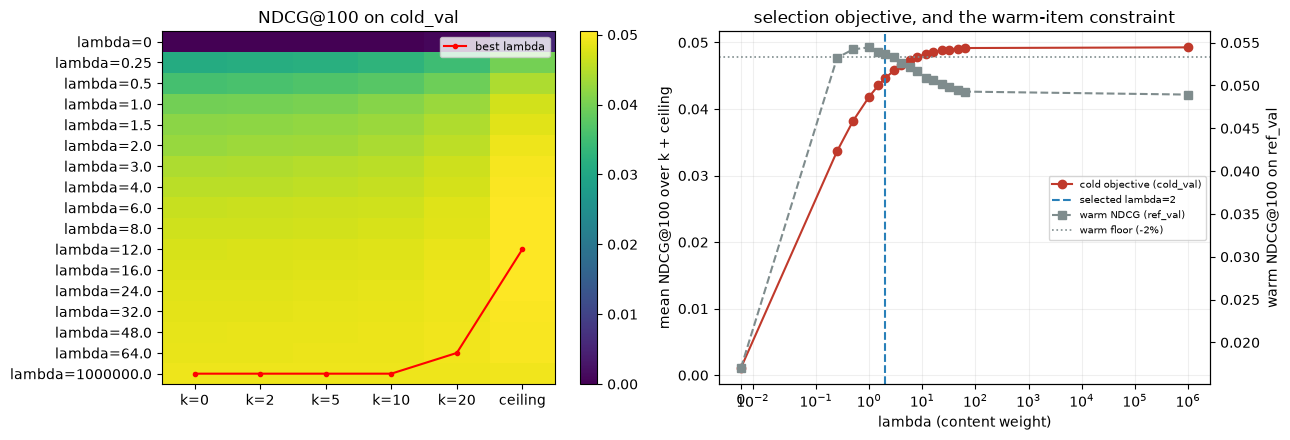

In [ ]:
%%time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
grid = np.array([[r["by_k"][SELECTOR][i] for i in range(len(K_LEVELS_TUNE))] + [r["ceiling"][SELECTOR]]
                 for r in rows])
im = ax1.imshow(grid, aspect="auto", cmap="viridis")
ax1.set_xticks(range(len(K_LEVELS_TUNE) + 1))
ax1.set_xticklabels([f"k={k}" for k in K_LEVELS_TUNE] + ["ceiling"])
ax1.set_yticks(range(len(LAMBDA_GRID)))
ax1.set_yticklabels([f"lambda={l}" for l in LAMBDA_GRID])
ax1.set_title(f"{SELECTOR}@{K} on cold_val")
fig.colorbar(im, ax=ax1)
best_per_col = [LAMBDA_GRID[int(np.nanargmax(grid[:, c]))] for c in range(grid.shape[1])]
ax1.plot(range(grid.shape[1]), [LAMBDA_GRID.index(b) for b in best_per_col], "r.-", label="best lambda")
ax1.legend(fontsize=8)

ax2.plot(LAMBDA_GRID, scores, "o-", color="#c0392b", label=f"cold objective (cold_val)")
ax2.axvline(BEST_LAMBDA, color="#2980b9", linestyle="--", label=f"selected lambda={BEST_LAMBDA:g}")
ax2.set_xscale("symlog", linthresh=0.05)
ax2.set_xlabel("lambda (content weight)")
ax2.set_ylabel(f"mean {SELECTOR}@{K} over k + ceiling")
ax2.set_title("selection objective, and the warm-item constraint")
ax2.grid(alpha=0.2)
# The warm curve on a twin axis: the cold objective rises with lambda without limit, so the only
# thing that can stop it is warm-item quality falling through the floor.
ax2w = ax2.twinx()
ax2w.plot(LAMBDA_GRID, warm_scores, "s--", color="#7f8c8d", label=f"warm {SELECTOR} (ref_val)")
ax2w.axhline(warm_floor, color="#7f8c8d", linestyle=":", linewidth=1.2,
             label=f"warm floor (-{WARM_TOLERANCE:.0%})")
ax2w.set_ylabel(f"warm {SELECTOR}@{K} on ref_val")
h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax2w.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, fontsize=7, loc="center right")
plt.tight_layout()
plt.savefig("lambda_selection.png", dpi=120, bbox_inches="tight")
print("best lambda per column:", dict(zip([f"k={k}" for k in K_LEVELS_TUNE] + ["ceiling"], best_per_col)))

## Persist the selection

Stamped with the dataset fingerprint so the steel thread can refuse it if the split has changed.

In [ ]:
%%time
os.makedirs("../outputs", exist_ok=True)
path = "../outputs/hyperparams.json"
record = json.load(open(path)) if os.path.exists(path) else {}
record["cbhcf"] = {
    "content_weight": BEST_LAMBDA,
    "selected_on": (f"cold_val ({len(val.cold_item_ids):,} items), mean {SELECTOR}@{K} over "
                    f"k={K_LEVELS_TUNE} + within-item ceiling, {N_SEEDS_TUNE} seeds, "
                    f"subject to warm {SELECTOR}@{K} on ref_val within {WARM_TOLERANCE:.0%} of "
                    f"the best warm score in the grid"),
    "grid": LAMBDA_GRID,
    "k_levels": K_LEVELS_TUNE,
    "K": K,
    "objective_by_lambda": {str(l): s for l, s in zip(LAMBDA_GRID, scores)},
    "warm_ndcg_by_lambda": {str(l): w for l, w in zip(LAMBDA_GRID, warm_scores)},
    # --- every metric, per lambda, not just the selector ------------------------------------------
    # The sweep above already computes all of ev.METRICS for every lambda; only NDCG used to be
    # persisted, so AUC was recomputed here, thrown away, and later had to be measured again by a
    # separate one-off script to compare against Intervention A. AUC is not a footnote on this
    # dataset: NDCG@100 over a ~247k candidate pool saturates near zero for cold items, so a
    # rank-based metric is the one that can still separate two methods that both look like ~0.04.
    "ndcg_by_k_by_lambda": {str(l): r["by_k"]["NDCG"] for l, r in zip(LAMBDA_GRID, rows)},
    "auc_by_k_by_lambda": {str(l): r["by_k"]["AUC"] for l, r in zip(LAMBDA_GRID, rows)},
    "ceiling_by_lambda": {str(l): r["ceiling"] for l, r in zip(LAMBDA_GRID, rows)},
    # The selected row, broken out so a consumer does not have to re-derive it from the grid.
    "coldval_at_selected_lambda": {
        "lambda": BEST_LAMBDA, "k_levels": K_LEVELS_TUNE, "K": K, "seeds": N_SEEDS_TUNE,
        "ndcg_by_k": rows[best_i]["by_k"]["NDCG"],
        "auc_by_k": rows[best_i]["by_k"]["AUC"],
        "ceiling_ndcg": rows[best_i]["ceiling"]["NDCG"],
        "ceiling_auc": rows[best_i]["ceiling"]["AUC"],
        "objective": scores[best_i],
        "warm_ndcg": warm_scores[best_i],
    },
    "warm_reference": warm_ref,
    "warm_floor": warm_floor,
    "warm_tolerance": WARM_TOLERANCE,
    "n_warm_eval_users": int(len(warm_eval_users)),
    "unconstrained_best_lambda": rows[unconstrained_i]["lambda"],
    "constraint_was_binding": bool(best_i != unconstrained_i),
    "best_lambda_per_column": dict(zip([f"k={k}" for k in K_LEVELS_TUNE] + ["ceiling"], best_per_col)),
    "seeds": N_SEEDS_TUNE,
    "als_params": ALS_PARAMS,
    "dataset_fingerprint": list(FP),
    "timestamp": time.strftime("%Y-%m-%dT%H:%M:%S"),
}
with open(path, "w") as f:
    json.dump(record, f, indent=2)
print(f"wrote {path}: cbhcf.content_weight = {BEST_LAMBDA}")
print(f"  sections preserved: {', '.join(sorted(k for k in record if k != 'cbhcf'))}")
print(f"  AUC@k0 at the selected lambda: {rows[best_i]['by_k']['AUC'][0]:.4f}   "
      f"ceiling AUC {rows[best_i]['ceiling']['AUC']:.4f}")